In [1]:
!pip install scikit-learn -i https://pypi.tuna.tsinghua.edu.cn/simple -q

100%|██████████| 1/1 [00:00<00:00,  1.29it/s]


结果保存的路径：/home/featurize/work/111_IR/消融实验-数据集选择-V2/output-Xception-V2/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup_训练策略_1t/paper_test所有图像预测标注.png


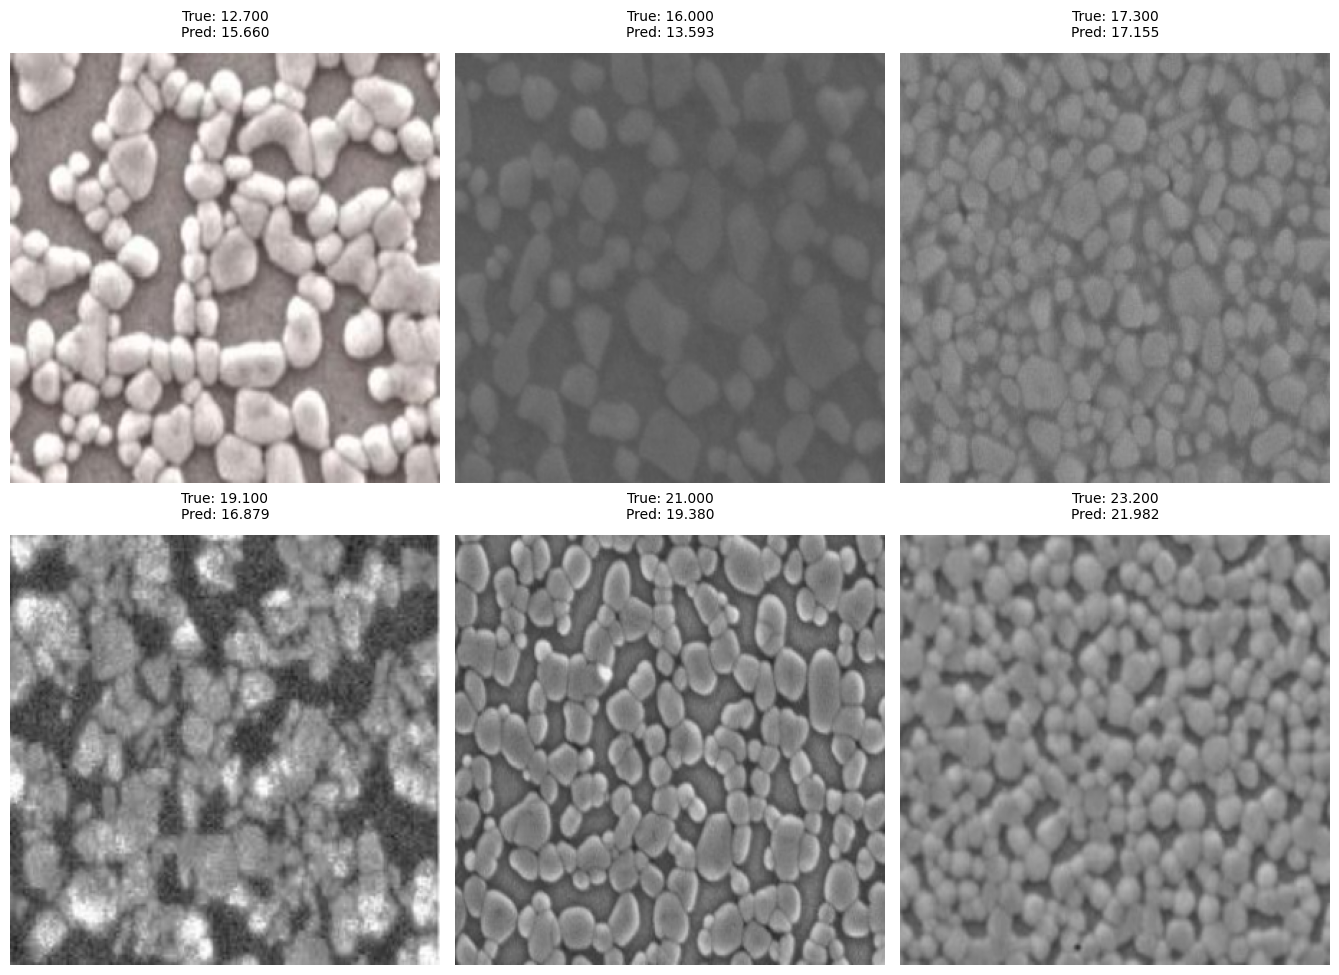

In [2]:
import os
import random
import warnings
import gc
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
gc.collect()

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 299
batch_size = 16
num_workers = 3
mean_values = [0.45564, 0.45563, 0.45561]
std_values = [0.13284, 0.13284, 0.13284]

model_weights_path = '/home/featurize/work/111_IR/消融实验-数据集选择-V2/output-Xception-V2/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup_训练策略_1t/Xception_MicroNet_MultiScale_CBAM_LIPCA_LRWarmup.pth'

paper_test_img_dir = Path('/home/featurize/work/111_IR/1-papar-test/test-paper')
paper_test_csv = Path('/home/featurize/work/111_IR/1-papar-test/test-paper.csv')

save_dir = Path(model_weights_path).parent
save_dir.mkdir(parents=True, exist_ok=True)

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_values, std=std_values)
])

visual_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor()
])

class SEMDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, visual_transform=None, target_transform=None):
        self.img_labels = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.visual_transform = visual_transform
        self.target_transform = target_transform
        
        missing_files = []
        for idx in range(len(self.img_labels)):
            img_path = self.img_dir / self.img_labels.iloc[idx, 0]
            if not img_path.exists():
                missing_files.append(str(img_path))

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_dir / self.img_labels.iloc[idx, 0]
        
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            image = Image.new('RGB', (img_size, img_size))
        
        label = float(self.img_labels.iloc[idx, 1])
        img_name = str(img_path.name)

        pred_image = self.transform(image) if self.transform else image
        visual_image = self.visual_transform(image) if self.visual_transform else image

        if self.target_transform:
            label = self.target_transform(label)

        return pred_image, visual_image, torch.tensor(label, dtype=torch.float32), img_name

class LIP(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(1) * 0.5)
        self.beta = nn.Parameter(torch.ones(1) * 0.5)

    def forward(self, x):
        var = torch.var(x, dim=(2, 3), keepdim=True)
        weight = F.softmax(var, dim=1)
        
        avg_pool = torch.mean(x, dim=(2, 3), keepdim=True)
        max_pool = torch.amax(x, dim=(2, 3), keepdim=True)
        
        lip_pool = self.alpha * (weight * avg_pool) + self.beta * ((1 - weight) * max_pool)
        return lip_pool

class ECA(nn.Module):
    def __init__(self, channel, gamma=2, b=1):
        super().__init__()
        t = int(abs((torch.log2(torch.tensor(channel, dtype=torch.float)) + b) / gamma))
        self.kernel_size = t if t % 2 == 1 else t + 1
        self.padding = self.kernel_size // 2
        
        self.conv = nn.Conv1d(1, 1, kernel_size=self.kernel_size, padding=self.padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        x = x.squeeze(-1).transpose(-1, -2)
        x = self.conv(x)
        x = x.transpose(-1, -2).unsqueeze(-1)
        channel_att = self.sigmoid(x)
        return channel_att

class CoordinateAttention(nn.Module):
    def __init__(self, channel, reduction=32):
        super().__init__()
        mid_channel = max(8, channel // reduction)
        
        self.conv1 = nn.Conv2d(1, mid_channel, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid_channel)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv_h = nn.Conv2d(mid_channel, channel, kernel_size=1, bias=False)
        self.conv_w = nn.Conv2d(mid_channel, channel, kernel_size=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()
        x_h = torch.mean(x, dim=3, keepdim=True)
        x_w = torch.mean(x, dim=2, keepdim=True)
        
        x_h_flat = x_h.view(b, c, h)
        x_w_flat = x_w.view(b, c, w)
        concat = torch.cat([x_h_flat, x_w_flat], dim=2).unsqueeze(1)
        
        concat = self.conv1(concat)
        concat = self.bn1(concat)
        concat = self.relu(concat)
        
        x_h, x_w = torch.split(concat, [h, w], dim=3)
        
        att_h = self.sigmoid(self.conv_h(x_h))
        att_h = att_h.mean(dim=2, keepdim=True)
        
        att_w = self.sigmoid(self.conv_w(x_w))
        att_w = att_w.mean(dim=2, keepdim=True)
        
        out = x * att_h * att_w
        return out

class CBAM_LIPCA(nn.Module):
    def __init__(self, channel, reduction=16, gamma=2, b=1):
        super().__init__()
        self.lip = LIP()
        self.eca = ECA(channel, gamma, b)
        self.coord_att = CoordinateAttention(channel, reduction)

    def forward(self, x):
        lip_out = self.lip(x)
        
        channel_att = self.eca(lip_out)
        x = x * channel_att
        
        refined_feat = self.coord_att(x)
        
        return refined_feat

class MultiScaleFusionWithCBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.cbam1 = CBAM_LIPCA(128)
        self.cbam2 = CBAM_LIPCA(256)
        self.cbam3 = CBAM_LIPCA(728)
        self.cbam4 = CBAM_LIPCA(2048)

        self.reduce_layer1 = nn.Conv2d(128, 256, kernel_size=1, bias=False)
        self.reduce_layer2 = nn.Conv2d(256, 256, kernel_size=1, bias=False)
        self.reduce_layer3 = nn.Conv2d(728, 256, kernel_size=1, bias=False)
        self.reduce_layer4 = nn.Conv2d(2048, 256, kernel_size=1, bias=False)

        self.fusion_conv = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, feat1, feat2, feat3, feat4):
        feat1 = self.cbam1(feat1)
        feat2 = self.cbam2(feat2)
        feat3 = self.cbam3(feat3)
        feat4 = self.cbam4(feat4)

        feat1 = self.reduce_layer1(feat1)
        feat2 = self.reduce_layer2(feat2)
        feat3 = self.reduce_layer3(feat3)
        feat4 = self.reduce_layer4(feat4)

        feat1 = F.interpolate(feat1, size=(10,10), mode='bilinear', align_corners=False)
        feat2 = F.interpolate(feat2, size=(10,10), mode='bilinear', align_corners=False)
        feat3 = F.interpolate(feat3, size=(10,10), mode='bilinear', align_corners=False)

        fused_feat = torch.cat([feat1, feat2, feat3, feat4], dim=1)
        fused_feat = self.fusion_conv(fused_feat)
        return fused_feat

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=1, stride=1, padding=0, dilation=1, bias=False):
        super(SeparableConv2d, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, dilation, groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, 1, 1, bias=bias)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

class Block(nn.Module):
    def __init__(self, in_filters, out_filters, reps, strides=1, start_with_relu=True, grow_first=True):
        super(Block, self).__init__()

        if out_filters != in_filters or strides != 1:
            self.skip = nn.Conv2d(in_filters, out_filters, 1, stride=strides, bias=False)
            self.skipbn = nn.BatchNorm2d(out_filters)
        else:
            self.skip = None

        self.relu = nn.ReLU(inplace=True)
        rep = []

        filters = in_filters
        if grow_first:
            rep.append(self.relu)
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1, bias=False))
            rep.append(nn.BatchNorm2d(out_filters))
            filters = out_filters

        for i in range(reps - 1):
            rep.append(self.relu)
            rep.append(SeparableConv2d(filters, filters, 3, stride=1, padding=1, bias=False))
            rep.append(nn.BatchNorm2d(filters))

        if not grow_first:
            rep.append(self.relu)
            rep.append(SeparableConv2d(in_filters, out_filters, 3, stride=1, padding=1, bias=False))
            rep.append(nn.BatchNorm2d(out_filters))

        if not start_with_relu:
            rep = rep[1:]
        else:
            rep[0] = nn.ReLU(inplace=False)

        if strides != 1:
            rep.append(nn.MaxPool2d(3, strides, 1))
        self.rep = nn.Sequential(*rep)

    def forward(self, inp):
        x = self.rep(inp)

        if self.skip is not None:
            skip = self.skip(inp)
            skip = self.skipbn(skip)
        else:
            skip = inp

        x += skip
        return x

class Xception(nn.Module):
    def __init__(self, num_classes=1000):
        super(Xception, self).__init__()
        
        self.num_classes = num_classes

        self.conv1 = nn.Conv2d(3, 32, 3, 2, 0, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(32, 64, 3, bias=False)
        self.bn2 = nn.BatchNorm2d(64)

        self.block1 = Block(64, 128, 2, 2, start_with_relu=False, grow_first=True)
        self.block2 = Block(128, 256, 2, 2, start_with_relu=True, grow_first=True)
        self.block3 = Block(256, 728, 2, 2, start_with_relu=True, grow_first=True)

        self.block4 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block5 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block6 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block7 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block8 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block9 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block10 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)
        self.block11 = Block(728, 728, 3, 1, start_with_relu=True, grow_first=True)

        self.block12 = Block(728, 1024, 2, 2, start_with_relu=True, grow_first=False)

        self.conv3 = SeparableConv2d(1024, 1536, 3, 1, 1)
        self.bn3 = nn.BatchNorm2d(1536)

        self.conv4 = SeparableConv2d(1536, 2048, 3, 1, 1)
        self.bn4 = nn.BatchNorm2d(2048)

        self.fc = nn.Linear(2048, num_classes)

class SEM_Model_MicroNet_MultiScale_CBAM(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.conv2,
            backbone.bn2,
            backbone.relu
        )

        self.block1 = backbone.block1
        self.block2 = backbone.block2
        self.block3 = nn.Sequential(
            backbone.block3, backbone.block4, backbone.block5,
            backbone.block6, backbone.block7, backbone.block8,
            backbone.block9, backbone.block10, backbone.block11
        )
        self.block4 = nn.Sequential(
            backbone.block12, backbone.conv3, backbone.bn3, backbone.relu,
            backbone.conv4, backbone.bn4, backbone.relu
        )

        self.ms_fusion_cbam = MultiScaleFusionWithCBAM()

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(512),  
            nn.Dropout(0.05),      
            nn.Linear(512, 256),  
            nn.ReLU(),           
            nn.Linear(256, 1)     
        )

    def forward(self, x):
        x = self.stem(x)
        feat1 = self.block1(x)
        feat2 = self.block2(feat1)
        feat3 = self.block3(feat2)
        feat4 = self.block4(feat3)

        fused_feat = self.ms_fusion_cbam(feat1, feat2, feat3, feat4)
        
        out = self.head(fused_feat).squeeze(-1)
        return out

def calc_metrics(preds, targets):
    preds = preds.cpu().numpy() if isinstance(preds, torch.Tensor) else preds
    targets = targets.cpu().numpy() if isinstance(targets, torch.Tensor) else targets
    r2 = r2_score(targets, preds)
    mae = mean_absolute_error(targets, preds)
    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    return r2, mae, mse, rmse

def calc_rmspe(preds, targets):
    preds = np.asarray(preds)
    targets = np.asarray(targets)
    targets_safe = targets + 1e-8
    percentage_errors = (preds - targets_safe) / targets_safe
    rmspe = np.sqrt(np.mean(np.square(percentage_errors))) * 100  
    return rmspe

base_model = Xception(num_classes=1000)
model = SEM_Model_MicroNet_MultiScale_CBAM(base_model).to(device)

checkpoint = torch.load(model_weights_path, map_location=device)
model.load_state_dict(checkpoint, strict=False)

model.eval()

paper_test_df = pd.read_csv(paper_test_csv)

paper_test_dataset = SEMDataset(
    paper_test_df, 
    paper_test_img_dir, 
    transform=test_transform,
    visual_transform=visual_transform
)

paper_test_loader = DataLoader(
    paper_test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers,
    pin_memory=True if torch.cuda.is_available() else False
)

paper_preds, paper_targs, paper_fnames, paper_visual_imgs = [], [], [], []

with torch.no_grad():
    for pred_imgs, visual_imgs, labels, filenames in tqdm(paper_test_loader):
        pred_imgs = pred_imgs.to(device, non_blocking=True)
        outputs = model(pred_imgs)
        
        paper_preds.extend(outputs.cpu().numpy())
        paper_targs.extend(labels.numpy())
        paper_fnames.extend(filenames)
        paper_visual_imgs.extend(visual_imgs)

df_paper_test = pd.DataFrame({
    "图像文件名": paper_fnames,
    "真实EQE值": paper_targs,
    "预测EQE值": paper_preds,
    "绝对误差": np.abs(np.array(paper_preds) - np.array(paper_targs)),
    "相对误差(%)": np.abs(np.array(paper_preds) - np.array(paper_targs)) / (np.array(paper_targs) + 1e-8) * 100
})

df_paper_test = df_paper_test.sort_values(by="绝对误差", ascending=False).reset_index(drop=True)


n_images = len(paper_visual_imgs)
n_cols = min(3, n_images)
n_rows = (n_images + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 4.5, n_rows * 5))

for i in range(n_images):
    img = paper_visual_imgs[i].permute(1, 2, 0).numpy()
    true_val = paper_targs[i]
    pred_val = paper_preds[i]
    
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(img)
    plt.title(f"True: {true_val:.3f}\nPred: {pred_val:.3f}", 
              fontsize=10, pad=12)
    plt.axis('off')

plt.tight_layout()

visualization_path = save_dir / "paper_test所有图像预测标注.png"
plt.savefig(visualization_path, dpi=200, bbox_inches='tight')

print(f"结果保存的路径：{visualization_path}")